<a href="https://colab.research.google.com/github/LuisMesa10/CasoLogistica_Bavaria/blob/main/CasoLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
ruta = "/content/drive/MyDrive/Caso Logistica/Caso Para Resolver PRACTICANTE LOGISTICA.xlsx"
import pandas as pd
import numpy as np



excel = pd.ExcelFile(ruta)

print("Hojas disponibles:")
print(excel.sheet_names)


df_ventas = pd.read_excel(
    ruta,
    sheet_name="Ventas",
    header=1
)

df_maestra = pd.read_excel(
    ruta,
    sheet_name="Maestra",
    header=0
)

# Normalizar nombres de columnas
df_ventas.columns = df_ventas.columns.str.strip().str.upper()
df_maestra.columns = df_maestra.columns.str.strip().str.upper()



# =========================================================
# 6. VISUALIZAR PRIMERAS FILAS
# =========================================================
print("\n--- VENTAS (head) ---")
display(df_ventas.head())

print("\n--- MAESTRA (head) ---")
display(df_maestra.head())


# =========================================================
# 7. REVISAR COLUMNAS
# =========================================================
print("\nColumnas Ventas:")
print(df_ventas.columns)

print("\nColumnas Maestra:")
print(df_maestra.columns)





Hojas disponibles:
['Cuestionario', 'Ventas', 'Maestra']

--- VENTAS (head) ---


,MES,REGIONAL,GERENCIA,SKU,VOL
0,Mayo,C100,C1A,26,936
1,Mayo,C100,C1A,26,1570
2,Mayo,C100,C1A,26,1723
3,Mayo,C100,C1C,26,686
4,Mayo,C100,C1C,26,1765



--- MAESTRA (head) ---


,SKU,MARCA,ENVASE,CAPACIDAD
0,1,Aguila,RB,300.0
1,2,Poker,RB,300.0
2,3,Club Colombia,RB,300.0
3,4,Pilsen,RB,300.0
4,5,Costena,RB,350.0



Columnas Ventas:
Index(['MES', 'REGIONAL', 'GERENCIA', 'SKU', 'VOL'], dtype='object')

Columnas Maestra:
Index(['SKU', 'MARCA', 'ENVASE', 'CAPACIDAD'], dtype='object')


In [9]:
# =========================================================
# BLOQUE 2 — ENRIQUECER VENTAS CON LA MAESTRA DE PRODUCTOS
# =========================================================

# 1. Revisar columnas disponibles
print("Columnas df_ventas:")
print(df_ventas.columns)

print("\nColumnas df_maestra:")
print(df_maestra.columns)


# 2. Revisar duplicados en la maestra por SKU
duplicados_maestra = df_maestra[df_maestra.duplicated(subset=["SKU"], keep=False)]

print("\nSKUs duplicados en Maestra:")
display(duplicados_maestra)


# 3. Si hay duplicados, conservar solo el primer registro por SKU
df_maestra_limpia = df_maestra.drop_duplicates(subset=["SKU"]).copy()

print("\nDimensiones maestra original:", df_maestra.shape)
print("Dimensiones maestra limpia:", df_maestra_limpia.shape)


# 4. Unir ventas con maestra usando SKU
df = df_ventas.merge(
    df_maestra_limpia,
    on="SKU",
    how="left"
)


# 5. Revisar resultado
print("\nDataset consolidado:")
display(df.head())

print("\nDimensiones del dataset consolidado:")
print(df.shape)


# 7. Revisar columnas finales
print("\nColumnas finales:")
print(df.columns)

Columnas df_ventas:
Index(['MES', 'REGIONAL', 'GERENCIA', 'SKU', 'VOL'], dtype='object')

Columnas df_maestra:
Index(['SKU', 'MARCA', 'ENVASE', 'CAPACIDAD'], dtype='object')

SKUs duplicados en Maestra:


,SKU,MARCA,ENVASE,CAPACIDAD



Dimensiones maestra original: (5535, 4)
Dimensiones maestra limpia: (5535, 4)

Dataset consolidado:


,MES,REGIONAL,GERENCIA,SKU,VOL,MARCA,ENVASE,CAPACIDAD
0,Mayo,C100,C1A,26,936,Aguila,KEG,50000.0
1,Mayo,C100,C1A,26,1570,Aguila,KEG,50000.0
2,Mayo,C100,C1A,26,1723,Aguila,KEG,50000.0
3,Mayo,C100,C1C,26,686,Aguila,KEG,50000.0
4,Mayo,C100,C1C,26,1765,Aguila,KEG,50000.0



Dimensiones del dataset consolidado:
(44016, 8)

Columnas finales:
Index(['MES', 'REGIONAL', 'GERENCIA', 'SKU', 'VOL', 'MARCA', 'ENVASE',
       'CAPACIDAD'],
      dtype='object')


In [12]:
# =========================================================
# BLOQUE 3 - crear dataset para responder preguntas
# =========================================================

# ---------------------------------------------------------
# 1. Verificar columnas clave
# ---------------------------------------------------------
columnas_esperadas = ["MES", "SKU", "VOL"]

faltantes = [col for col in columnas_esperadas if col not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas clave: {faltantes}")

print("Columnas clave OK.")


# ---------------------------------------------------------
# 2. Normalizar texto
# ---------------------------------------------------------
df["MES"] = df["MES"].astype(str).str.strip().str.upper()
df["MARCA"] = df["MARCA"].astype(str).str.strip().str.upper()
df["ENVASE"] = df["ENVASE"].astype(str).str.strip().str.upper()


# ---------------------------------------------------------
# 3. Limpiar volumen
# ---------------------------------------------------------
df["VOL"] = pd.to_numeric(df["VOL"], errors="coerce")

df = df.dropna(subset=["VOL"]).copy()


# ---------------------------------------------------------
# 4. Validar valores de MES
# ---------------------------------------------------------
print("\nValores únicos de MES:")
print(df["MES"].unique())


# ---------------------------------------------------------
# 5. Filtrar solo MAYO y JUNIO (si hay otros valores)
# ---------------------------------------------------------
df = df[df["MES"].isin(["MAYO", "JUNIO"])].copy()





# ---------------------------------------------------------
# 7. Totales por mes (control clave)
# ---------------------------------------------------------
totales_mes = df.groupby("MES")["VOL"].sum()

print("\nTotales por mes:")
print(totales_mes)


# ---------------------------------------------------------
# 8. Crear dataset base
# ---------------------------------------------------------
df_base = df.copy()

print("\nDataset listo para análisis: df_base")
print("Dimensiones:", df_base.shape)

display(df_base.head())

Columnas clave OK.

Valores únicos de MES:
['MAYO' 'JUNIO']

Totales por mes:
MES
JUNIO    22108317
MAYO     21942275
Name: VOL, dtype: int64

Dataset listo para análisis: df_base
Dimensiones: (44016, 8)


,MES,REGIONAL,GERENCIA,SKU,VOL,MARCA,ENVASE,CAPACIDAD
0,MAYO,C100,C1A,26,936,AGUILA,KEG,50000.0
1,MAYO,C100,C1A,26,1570,AGUILA,KEG,50000.0
2,MAYO,C100,C1A,26,1723,AGUILA,KEG,50000.0
3,MAYO,C100,C1C,26,686,AGUILA,KEG,50000.0
4,MAYO,C100,C1C,26,1765,AGUILA,KEG,50000.0


Dataset validado correctamente.

Tabla agregada por marca y mes:


,MARCA,MES,VOL
0,AGUILA,JUNIO,2005070
1,AGUILA,MAYO,1965848
2,AGUILA CERO,JUNIO,937753
3,AGUILA CERO,MAYO,931397
4,AGUILA LIGHT,JUNIO,1996436



Tabla pivot (Mayo vs Junio):


MES,JUNIO,MAYO
MARCA,,
AGUILA,2005070,1965848
AGUILA CERO,937753,931397
AGUILA LIGHT,1996436,1900689
AZTECA,231265,213167
BACATA BLANCA,28271,31451
BAHIA LIGHT,21924,17069
BECKS,171158,147812
BUDWEISER,2649,2518
BUDWEISER (CO),1306725,1324135



Tabla con crecimiento:


MES,JUNIO,MAYO,CRECIMIENTO_ABS,CRECIMIENTO_PCT
MARCA,,,,
AGUILA,2005070,1965848,39222,0.019952
AGUILA CERO,937753,931397,6356,0.006824
AGUILA LIGHT,1996436,1900689,95747,0.050375
AZTECA,231265,213167,18098,0.084901
BACATA BLANCA,28271,31451,-3180,-0.101110
BAHIA LIGHT,21924,17069,4855,0.284434
BECKS,171158,147812,23346,0.157944
BUDWEISER,2649,2518,131,0.052025
BUDWEISER (CO),1306725,1324135,-17410,-0.013148



Ranking de crecimiento por marca:


MES,JUNIO,MAYO,CRECIMIENTO_ABS,CRECIMIENTO_PCT
MARCA,,,,
AGUILA LIGHT,1996436,1900689,95747,0.050375
PONY MALTA,2614609,2532958,81651,0.032235
AGUILA,2005070,1965848,39222,0.019952
CORONA EXTRA,587186,560844,26342,0.046968
BECKS,171158,147812,23346,0.157944
CHAPINERO PORTER,191227,172479,18748,0.108697
AZTECA,231265,213167,18098,0.084901
COSTENITA,130260,114507,15753,0.137572
CLUB COLOMBIA NEGRA,1290408,1281635,8773,0.006845



Marca con mayor crecimiento:


MES,JUNIO,MAYO,CRECIMIENTO_ABS,CRECIMIENTO_PCT
MARCA,,,,
AGUILA LIGHT,1996436,1900689,95747,0.050375


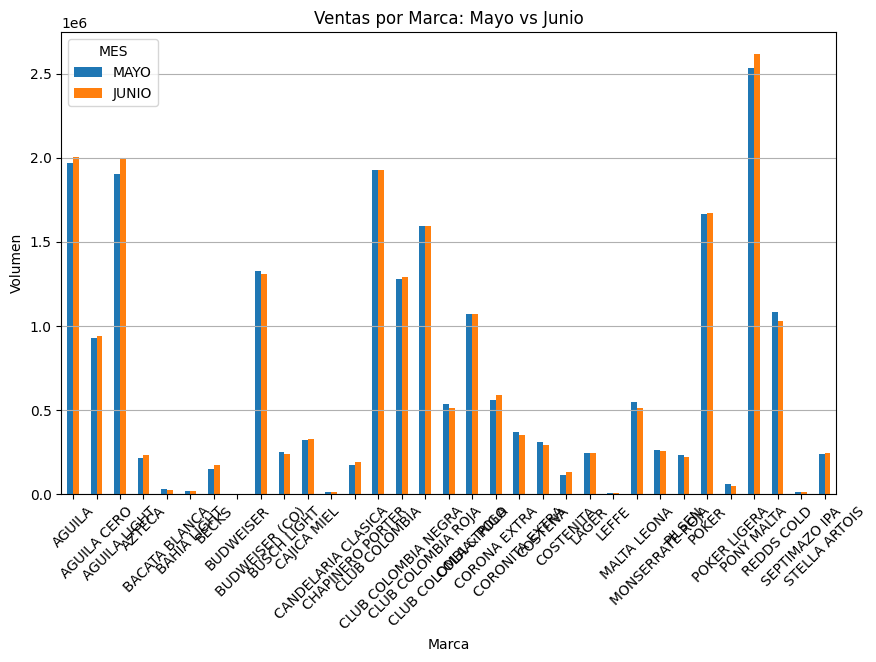


Totales por mes (control):
MES
JUNIO    22108317
MAYO     21942275
Name: VOL, dtype: int64


In [13]:
# =========================================================
# BLOQUE 4 COMPLETO — CRECIMIENTO POR MARCA (MAYO vs JUNIO)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Validación mínima del dataset base
# ---------------------------------------------------------
columnas_necesarias = ["MARCA", "MES", "VOL"]

faltantes = [col for col in columnas_necesarias if col not in df_base.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias en df_base: {faltantes}")

print("Dataset validado correctamente.")


# ---------------------------------------------------------
# 2. Agregación por MARCA y MES
# ---------------------------------------------------------
tabla_marca = (
    df_base
    .groupby(["MARCA", "MES"], as_index=False)["VOL"]
    .sum()
)

print("\nTabla agregada por marca y mes:")
display(tabla_marca.head())


# ---------------------------------------------------------
# 3. Convertir a formato comparativo (MAYO vs JUNIO)
# ---------------------------------------------------------
tabla_pivot = (
    tabla_marca
    .pivot(index="MARCA", columns="MES", values="VOL")
    .fillna(0)
)

print("\nTabla pivot (Mayo vs Junio):")
display(tabla_pivot)


# ---------------------------------------------------------
# 4. Cálculo de crecimiento
# ---------------------------------------------------------
tabla_pivot["CRECIMIENTO_ABS"] = tabla_pivot["JUNIO"] - tabla_pivot["MAYO"]

tabla_pivot["CRECIMIENTO_PCT"] = (
    tabla_pivot["CRECIMIENTO_ABS"] / tabla_pivot["MAYO"]
).replace([np.inf, -np.inf], 0)

print("\nTabla con crecimiento:")
display(tabla_pivot)


# ---------------------------------------------------------
# 5. Ranking de crecimiento
# ---------------------------------------------------------
ranking_crecimiento = tabla_pivot.sort_values(
    by="CRECIMIENTO_ABS",
    ascending=False
)

print("\nRanking de crecimiento por marca:")
display(ranking_crecimiento)


# ---------------------------------------------------------
# 6. Marca con mayor crecimiento
# ---------------------------------------------------------
top_marca = ranking_crecimiento.head(1)

print("\nMarca con mayor crecimiento:")
display(top_marca)


# ---------------------------------------------------------
# 7. Gráfico comparativo (requerido)
# ---------------------------------------------------------
tabla_pivot[["MAYO", "JUNIO"]].plot(kind="bar", figsize=(10,6))

plt.title("Ventas por Marca: Mayo vs Junio")
plt.ylabel("Volumen")
plt.xlabel("Marca")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


# ---------------------------------------------------------
# 8. Validación rápida de consistencia
# ---------------------------------------------------------
print("\nTotales por mes (control):")
print(df_base.groupby("MES")["VOL"].sum())

Columnas validadas.

Tabla agregada:


,ENVASE,MES,VOL
0,CAN,JUNIO,9197226
1,CAN,MAYO,9121249
2,KEG,JUNIO,310553
3,KEG,MAYO,289505
4,NRB,JUNIO,4982892
5,NRB,MAYO,4975059
6,PET,JUNIO,2517290
7,PET,MAYO,2411392
8,RB,JUNIO,5100356
9,RB,MAYO,5145070



Tabla pivot:


MES,JUNIO,MAYO
ENVASE,,
CAN,9197226,9121249
KEG,310553,289505
NRB,4982892,4975059
PET,2517290,2411392
RB,5100356,5145070



Resultados:
Mayor venta MAYO: CAN
Menor venta MAYO: KEG
Mayor venta JUNIO: CAN
Menor venta JUNIO: KEG


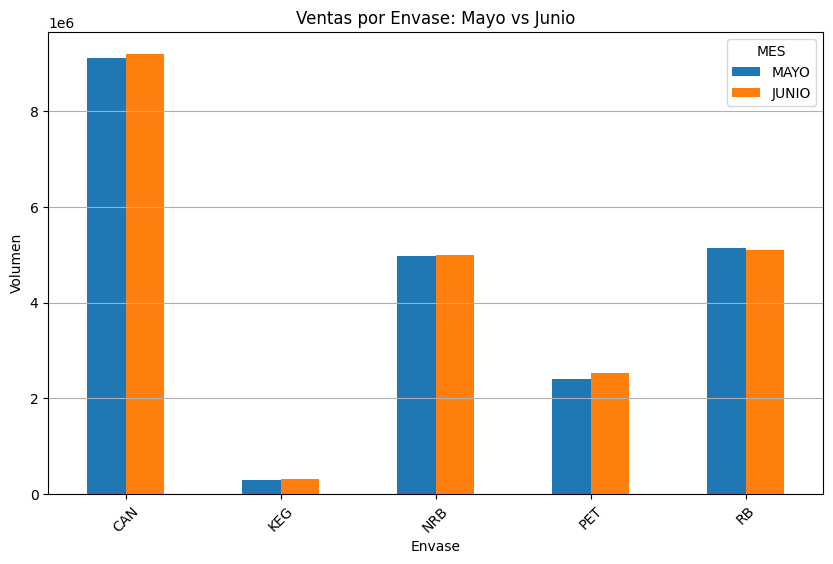


Totales por mes:
MES
JUNIO    22108317
MAYO     21942275
Name: VOL, dtype: int64


In [14]:
# =========================================================
# BLOQUE 5 — VENTAS POR ENVASE (MAYO vs JUNIO)
# =========================================================

# ---------------------------------------------------------
# 1. Validación
# ---------------------------------------------------------
columnas_necesarias = ["ENVASE", "MES", "VOL"]

faltantes = [col for col in columnas_necesarias if col not in df_base.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

print("Columnas validadas.")


# ---------------------------------------------------------
# 2. Agregar ventas por ENVASE y MES
# ---------------------------------------------------------
tabla_envase = (
    df_base
    .groupby(["ENVASE", "MES"], as_index=False)["VOL"]
    .sum()
)

print("\nTabla agregada:")
display(tabla_envase)


# ---------------------------------------------------------
# 3. Pivot para comparación
# ---------------------------------------------------------
tabla_envase_pivot = (
    tabla_envase
    .pivot(index="ENVASE", columns="MES", values="VOL")
    .fillna(0)
)

print("\nTabla pivot:")
display(tabla_envase_pivot)


# ---------------------------------------------------------
# 4. Identificar máximos y mínimos por mes
# ---------------------------------------------------------
# MAYO
envase_max_mayo = tabla_envase_pivot["MAYO"].idxmax()
envase_min_mayo = tabla_envase_pivot["MAYO"].idxmin()

# JUNIO
envase_max_junio = tabla_envase_pivot["JUNIO"].idxmax()
envase_min_junio = tabla_envase_pivot["JUNIO"].idxmin()

print("\nResultados:")
print(f"Mayor venta MAYO: {envase_max_mayo}")
print(f"Menor venta MAYO: {envase_min_mayo}")

print(f"Mayor venta JUNIO: {envase_max_junio}")
print(f"Menor venta JUNIO: {envase_min_junio}")


# ---------------------------------------------------------
# 5. Gráfico
# ---------------------------------------------------------
import matplotlib.pyplot as plt

tabla_envase_pivot[["MAYO", "JUNIO"]].plot(kind="bar", figsize=(10,6))

plt.title("Ventas por Envase: Mayo vs Junio")
plt.ylabel("Volumen")
plt.xlabel("Envase")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


# ---------------------------------------------------------
# 6. Validación rápida
# ---------------------------------------------------------
print("\nTotales por mes:")
print(df_base.groupby("MES")["VOL"].sum())

Columnas validadas.

Registros en junio: (22099, 8)

Tabla capacidad:


,CAPACIDAD,VOL
9,330.0,8819804
11,355.0,4033216
5,269.0,2548219
13,473.0,1176191
15,750.0,905516
17,1500.0,682699
4,250.0,669270
1,200.0,565644
16,1000.0,373177
2,207.0,350087



Capacidad más consumida en junio:


,CAPACIDAD,VOL
9,330.0,8819804


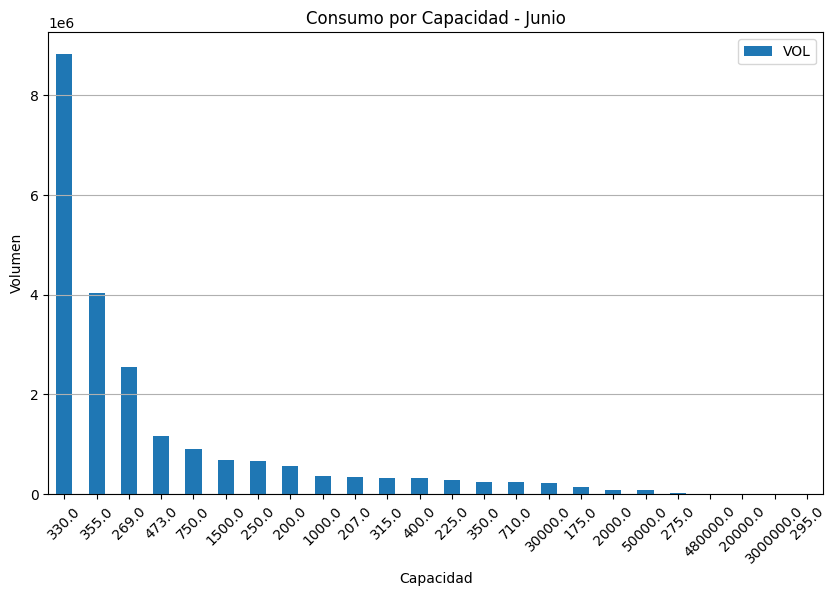


Total junio:
22108317


In [15]:
# =========================================================
# BLOQUE 6 — CAPACIDAD MÁS CONSUMIDA EN JUNIO
# =========================================================

# ---------------------------------------------------------
# 1. Validación
# ---------------------------------------------------------
columnas_necesarias = ["CAPACIDAD", "MES", "VOL"]

faltantes = [col for col in columnas_necesarias if col not in df_base.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

print("Columnas validadas.")


# ---------------------------------------------------------
# 2. Filtrar JUNIO
# ---------------------------------------------------------
df_junio = df_base[df_base["MES"] == "JUNIO"].copy()

print("\nRegistros en junio:", df_junio.shape)


# ---------------------------------------------------------
# 3. Agregar por CAPACIDAD
# ---------------------------------------------------------
tabla_capacidad = (
    df_junio
    .groupby("CAPACIDAD", as_index=False)["VOL"]
    .sum()
    .sort_values(by="VOL", ascending=False)
)

print("\nTabla capacidad:")
display(tabla_capacidad)


# ---------------------------------------------------------
# 4. Identificar capacidad líder
# ---------------------------------------------------------
capacidad_top = tabla_capacidad.head(1)

print("\nCapacidad más consumida en junio:")
display(capacidad_top)


# ---------------------------------------------------------
# 5. Gráfico
# ---------------------------------------------------------
import matplotlib.pyplot as plt

tabla_capacidad.plot(
    x="CAPACIDAD",
    y="VOL",
    kind="bar",
    figsize=(10,6)
)

plt.title("Consumo por Capacidad - Junio")
plt.ylabel("Volumen")
plt.xlabel("Capacidad")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


# ---------------------------------------------------------
# 6. Validación
# ---------------------------------------------------------
print("\nTotal junio:")
print(df_junio["VOL"].sum())

In [16]:
# =========================================================
# BLOQUE 7 — PROYECCIÓN DE VENTAS JULIO POR SKU
# =========================================================

# ---------------------------------------------------------
# 1. Validación
# ---------------------------------------------------------
columnas_necesarias = ["SKU", "MES", "VOL"]

faltantes = [col for col in columnas_necesarias if col not in df_base.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

print("Columnas validadas.")


# ---------------------------------------------------------
# 2. Agregar ventas por SKU y MES
# ---------------------------------------------------------
tabla_sku = (
    df_base
    .groupby(["SKU", "MES"], as_index=False)["VOL"]
    .sum()
)

print("\nTabla SKU-MES:")
display(tabla_sku.head())


# ---------------------------------------------------------
# 3. Pivot para comparar MAYO vs JUNIO
# ---------------------------------------------------------
tabla_sku_pivot = (
    tabla_sku
    .pivot(index="SKU", columns="MES", values="VOL")
    .fillna(0)
)

print("\nTabla pivot SKU:")
display(tabla_sku_pivot.head())


# ---------------------------------------------------------
# 4. Proyección de JULIO
# ---------------------------------------------------------
tabla_sku_pivot["PROY_JULIO"] = (
    tabla_sku_pivot["JUNIO"] +
    (tabla_sku_pivot["JUNIO"] - tabla_sku_pivot["MAYO"])
)

print("\nTabla con proyección:")
display(tabla_sku_pivot.head())


# ---------------------------------------------------------
# 5. Ranking de SKUs por proyección
# ---------------------------------------------------------
ranking_sku = tabla_sku_pivot.sort_values(
    by="PROY_JULIO",
    ascending=False
)

print("\nRanking de SKUs proyectados:")
display(ranking_sku.head(10))


# ---------------------------------------------------------
# 6. Identificar SKU líder
# ---------------------------------------------------------
top_sku = ranking_sku.head(1)

print("\nSKU con mayor probabilidad de venta en julio:")
display(top_sku)


# ---------------------------------------------------------
# 7. Traer atributos del producto
# (marca, envase, capacidad)
# ---------------------------------------------------------
info_producto = (
    df_base[["SKU", "MARCA", "ENVASE", "CAPACIDAD"]]
    .drop_duplicates()
)

top_sku_detalle = top_sku.reset_index().merge(
    info_producto,
    on="SKU",
    how="left"
)

print("\nDetalle del SKU líder:")
display(top_sku_detalle)

Columnas validadas.

Tabla SKU-MES:


,SKU,MES,VOL
0,26,JUNIO,69770
1,26,MAYO,69109
2,27,JUNIO,6194
3,27,MAYO,5063
4,31,JUNIO,97422



Tabla pivot SKU:


MES,JUNIO,MAYO
SKU,,
26,69770.0,69109.0
27,6194.0,5063.0
31,97422.0,92978.0
340,943.0,1408.0
1421,292210.0,301116.0



Tabla con proyección:


...

MES,JUNIO,MAYO,PROY_JULIO
SKU,,,
2160,327011.0,290554.0,363468.0
2170,330253.0,325068.0,335438.0
5904,273594.0,223686.0,323502.0
2224,315786.0,308101.0,323471.0
3759,301169.0,286127.0,316211.0
8135,293478.0,272669.0,314287.0
7991,310618.0,309682.0,311554.0
7078,316779.0,322894.0,310664.0
3128,294119.0,283119.0,305119.0



SKU con mayor probabilidad de venta en julio:


MES,JUNIO,MAYO,PROY_JULIO
SKU,,,
2160,327011.0,290554.0,363468.0



Detalle del SKU líder:


,SKU,JUNIO,MAYO,PROY_JULIO,MARCA,ENVASE,CAPACIDAD
0,2160,327011.0,290554.0,363468.0,AGUILA LIGHT,RB,330.0


## Metodología de análisis

Para dar respuesta a las preguntas planteadas, se desarrolló un flujo de análisis en Python (Google Colab) utilizando la librería pandas, con el objetivo de garantizar trazabilidad, consistencia y escalabilidad en el tratamiento de los datos.

### 1. Carga y entendimiento de la información

Inicialmente, se cargó el archivo de Excel desde Google Drive, identificando las hojas de trabajo correspondientes a ventas y a la información maestra de productos. Durante esta etapa se detectó que la hoja de ventas presentaba una estructura no estándar (encabezados desplazados), por lo que se ajustó la lectura para asegurar una correcta interpretación de las columnas.

Posteriormente, se normalizaron los nombres de las columnas (eliminando espacios y unificando en mayúsculas) para evitar inconsistencias en el procesamiento.

### 2. Integración de la información

Se realizó la unión entre la tabla de ventas y la tabla maestra mediante la variable SKU, lo que permitió enriquecer cada registro de venta con atributos del producto como:

*   Marca
*   Envase
*   Capacidad

La unión se realizó bajo un enfoque tipo `left join`, con el fin de preservar la totalidad de las ventas, incluso en casos donde pudiera faltar información en la tabla maestra.

### 3. Validación y limpieza de datos

Una vez consolidado el dataset, se llevaron a cabo procesos de validación y limpieza:

*   Estandarización de variables categóricas (MES, MARCA, ENVASE)
*   Conversión de la variable de volumen (VOL) a formato numérico
*   Eliminación de registros con valores nulos en variables críticas
*   Filtrado de los meses relevantes para el análisis (mayo y junio)

Como resultado, se obtuvo un dataset final (`df_base`) en formato largo, donde cada fila representa una combinación de producto, ubicación y mes, junto con su volumen de ventas.

## Análisis realizados

### 4. Crecimiento por marca (Mayo vs Junio)

Se realizó una agregación de las ventas por marca y mes, calculando el volumen total vendido en cada periodo. Posteriormente, se estructuró la información en formato comparativo para evaluar directamente la variación entre mayo y junio.

Se calcularon dos métricas clave:

*   **Crecimiento absoluto**: diferencia de volumen entre junio y mayo
*   **Crecimiento porcentual**: variación relativa respecto al volumen base de mayo

Esto permitió identificar la marca con mayor aporte al crecimiento en términos de volumen, así como analizar la dinámica relativa de crecimiento entre marcas.

Adicionalmente, se generó un gráfico de barras para visualizar la comparación entre ambos meses.

### 5. Análisis por envase

Se agruparon las ventas por tipo de envase y mes, permitiendo identificar:

*   El envase con mayor volumen de ventas
*   El envase con menor participación

Este análisis evidenció la concentración del volumen en ciertos tipos de envase y permitió evaluar la consistencia del comportamiento entre mayo y junio.

### 6. Capacidad más consumida en junio

Se filtraron los datos correspondientes a junio y se agregaron las ventas por capacidad (cc), identificando la presentación con mayor consumo.

Este análisis permite entender la preferencia del mercado en términos de tamaño de producto, lo cual es relevante para decisiones de producción y distribución.

### 7. Proyección de ventas (julio)

Finalmente, se realizó una estimación del comportamiento de ventas para julio a nivel de SKU, utilizando un modelo de tendencia lineal simple basado en la variación observada entre mayo y junio.

La proyección se calculó como:

`Julio = Junio + (Junio – Mayo)`

Con base en esta estimación, se identificó el SKU con mayor volumen proyectado, incorporando además su información de marca, envase y capacidad para una interpretación integral.

Es importante destacar que esta proyección es una aproximación simplificada, ya que no considera factores como estacionalidad, restricciones logísticas o variaciones en la demanda.